# EEG Go/NoGo · Response-Locked MRCP Classification (gng2)

Response-locked epoch classification:
- **Positive**: `[-1.5 s, 0]` before each button press (GO hits)
- **Negative**: `[-1.5 s, 0]` before virtual press = nogo cue + median GO RT

Pipeline: `bandpass 0.5–4 Hz → CAR → MRCP features → shrinkage LDA`

Leave-one-session-out cross-validation.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mne.filter import filter_data
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

## Config

In [2]:
ROOT = "../data/subjectV"
DATE = "20260617"
FS   = 250.0

EPOCH_S       = 1.5
N_EPOCH       = int(EPOCH_S * FS)          # 375 samples
LATE_MS       = 200
N_LATE        = int(LATE_MS / 1000 * FS)   # 50 samples
LATE_SLOPE_MS = 500
N_LATE_SLOPE  = int(LATE_SLOPE_MS / 1000 * FS)  # 125 samples
N_SEGS        = 6

# MRCP is maximal at central/frontocentral/parietal electrodes
# 10-20: FP1=0 F3=1 F7=2 C3=3 T3=4 P3=5 T5=6 O1=7
#        FP2=8 F4=9 F8=10 C4=11 T4=12 P4=13 T6=14 O2=15
ALL_COLS      = [f"ch{i}" for i in range(16)]
CENTRAL_IDX   = [1, 3, 5, 9, 11, 13]       # F3 C3 P3 F4 C4 P4
CENTRAL_NAMES = ["F3", "C3", "P3", "F4", "C4", "P4"]
N_CH = len(CENTRAL_IDX)

SEED = 42
print(f"N_EPOCH={N_EPOCH}  N_LATE={N_LATE}  N_LATE_SLOPE={N_LATE_SLOPE}")
print(f"Channels ({N_CH}): {CENTRAL_NAMES}")

N_EPOCH=375  N_LATE=50  N_LATE_SLOPE=125
Channels (6): ['F3', 'C3', 'P3', 'F4', 'C4', 'P4']


## Load & Preprocess

In [3]:
stamps = sorted(
    f.split("_")[-1][:-4]
    for f in os.listdir(ROOT)
    if f.startswith("V_eeg_") and f.endswith(".csv")
)
print(f"Found {len(stamps)} sessions: {stamps}")

sessions = {}   # stamp → (timestamps, eeg (N, N_CH), mrk_df)

for stamp in stamps:
    eeg_df = pd.read_csv(f"{ROOT}/V_eeg_{DATE}_{stamp}.csv")
    mrk_df = pd.read_csv(f"{ROOT}/V_markers_{DATE}_{stamp}.csv")

    raw_ts  = eeg_df["lsl_timestamp"].values
    raw_eeg = eeg_df[ALL_COLS].values.astype(np.float64)

    # bandpass 0.5–4 Hz on all channels, then CAR
    filt = filter_data(raw_eeg.T, FS, 0.5, 4.0, verbose=False).T
    filt -= filt.mean(axis=1, keepdims=True)

    # select central channels
    eeg_central = filt[:, CENTRAL_IDX].astype(np.float32)

    sessions[stamp] = (raw_ts, eeg_central, mrk_df)
    print(f"  {stamp}: {len(eeg_central):,} samples  {len(mrk_df)} markers")

Found 6 sessions: ['150226', '163354', '164144', '164714', '165256', '165815']
  150226: 87,304 samples  275 markers
  163354: 67,584 samples  251 markers
  164144: 64,981 samples  251 markers
  164714: 64,082 samples  253 markers
  165256: 65,556 samples  251 markers
  165815: 65,656 samples  252 markers


## Epoch Extraction

Both classes are aligned to the same task phase:
- **GO**: window ends at button press
- **NoGo**: window ends at `nogo_cue + median_RT` (virtual press)

In [4]:
def extract_epochs_session(stamp):
    """Returns raw (n, N_EPOCH, N_CH), labels (n,), median_rt."""
    ts, data, mrk = sessions[stamp]

    go_ts    = mrk.loc[mrk.marker_label == "go_onset",     "lsl_timestamp"].values
    hit_ts   = mrk.loc[mrk.marker_label == "hit",          "lsl_timestamp"].values
    press_ts = mrk.loc[mrk.marker_label == "button_press", "lsl_timestamp"].values
    nogo_ts  = mrk.loc[mrk.marker_label == "nogo_onset",   "lsl_timestamp"].values

    rts = [h - go_ts[go_ts < h][-1] for h in hit_ts if len(go_ts[go_ts < h])]
    median_rt = float(np.median(rts)) if rts else 0.8
    virtual_press_ts = nogo_ts + median_rt

    epochs, labels = [], []
    for ts_arr, label in [(press_ts, 1), (virtual_press_ts, 0)]:
        for ts0 in ts_arr:
            idx   = np.searchsorted(ts, ts0)
            start = idx - N_EPOCH
            if start >= 0 and idx <= len(data):
                epochs.append(data[start:idx])
                labels.append(label)

    return np.array(epochs, dtype=np.float32), np.array(labels, dtype=np.int8), median_rt


all_raw, all_y, all_sid = [], [], []
for sid, stamp in enumerate(stamps):
    raw, y, med_rt = extract_epochs_session(stamp)
    print(f"  Session {sid} ({stamp}): {(y==1).sum()} pos  {(y==0).sum()} neg  "
          f"median RT={med_rt*1000:.0f} ms")
    all_raw.append(raw)
    all_y.append(y)
    all_sid.append(np.full(len(y), sid, dtype=np.int32))

raw_all = np.concatenate(all_raw)   # (M, N_EPOCH, N_CH)
y_all   = np.concatenate(all_y)
s_all   = np.concatenate(all_sid)
print(f"\nTotal: {len(y_all)} epochs  {y_all.sum()} pos  shape {raw_all.shape}")

  Session 0 (150226): 73 pos  25 neg  median RT=499 ms
  Session 1 (163354): 49 pos  50 neg  median RT=592 ms
  Session 2 (164144): 50 pos  49 neg  median RT=605 ms
  Session 3 (164714): 52 pos  49 neg  median RT=474 ms
  Session 4 (165256): 49 pos  50 neg  median RT=359 ms
  Session 5 (165815): 51 pos  49 neg  median RT=340 ms

Total: 596 epochs  324 pos  shape (596, 375, 6)


## Grand-Average MRCP

Visual sanity check before classification.

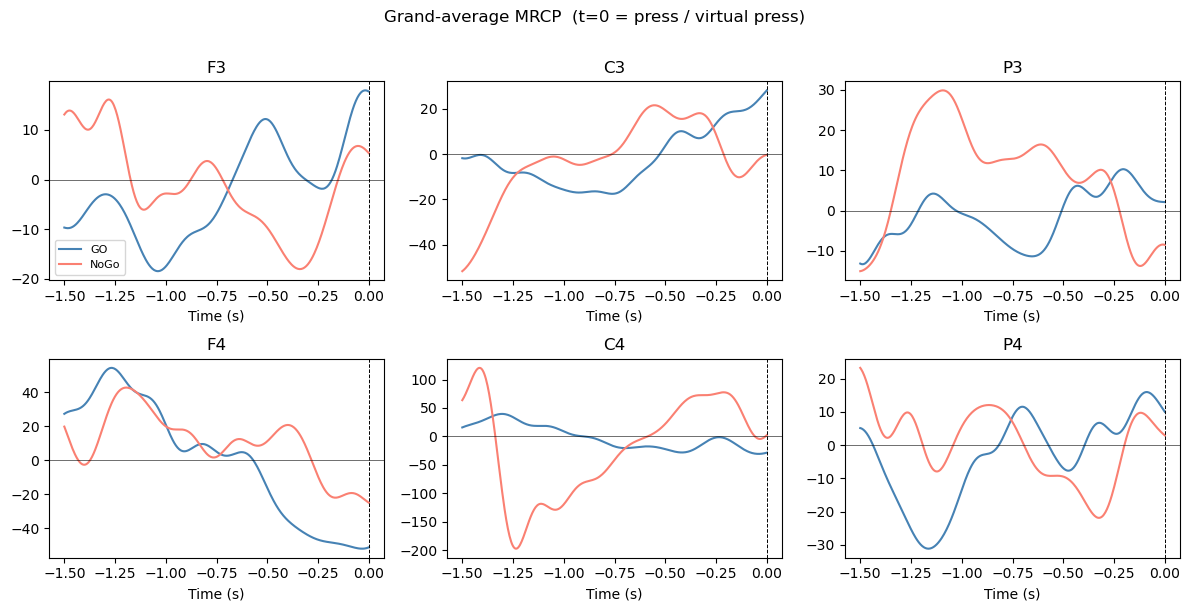

In [7]:
%matplotlib inline

t_ax = np.linspace(-EPOCH_S, 0, N_EPOCH)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (ch_i, ch_name) in zip(axes.flat, enumerate(CENTRAL_NAMES)):
    go_mean   = raw_all[y_all == 1][:, :, ch_i].mean(0)
    nogo_mean = raw_all[y_all == 0][:, :, ch_i].mean(0)
    ax.plot(t_ax, go_mean,   label="GO",   color="steelblue")
    ax.plot(t_ax, nogo_mean, label="NoGo", color="salmon")
    ax.axvline(0, color="k", linewidth=0.7, linestyle="--")
    ax.axhline(0, color="k", linewidth=0.4)
    ax.set_title(ch_name)
    ax.set_xlabel("Time (s)")
    if ch_i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Grand-average MRCP  (t=0 = press / virtual press)", y=1.01)
plt.tight_layout()
plt.show()

## Features

11 MRCP-specific features × 6 channels = 66 total.

| Feature | Captures |
|---|---|
| mean | slow negativity level |
| slope | overall ramp direction |
| 6 segment means | temporal profile |
| late mean (200 ms) | peak BP amplitude |
| late slope (500 ms) | NS′ steepness |
| delta power (0.5–4 Hz) | MRCP-band energy |

In [8]:
def epoch_features(epoch):
    """epoch: (N_EPOCH, N_CH) → float32 vector, length N_CH * (N_SEGS + 5)."""
    T = epoch.shape[0]
    baseline = epoch[:int(0.1 * FS)].mean(axis=0)
    ep = epoch - baseline

    t_c = np.arange(T, dtype=np.float64) - T / 2

    feat_mean  = ep.mean(axis=0)
    feat_slope = (ep * t_c[:, None]).sum(axis=0) / (t_c ** 2).sum()

    seg_size  = T // N_SEGS
    feat_segs = np.stack(
        [ep[i*seg_size:(i+1)*seg_size].mean(axis=0) for i in range(N_SEGS)]
    ).T.flatten()

    feat_late = ep[-N_LATE:].mean(axis=0)

    ep_ls = ep[-N_LATE_SLOPE:]
    t_ls  = np.arange(N_LATE_SLOPE, dtype=np.float64) - N_LATE_SLOPE / 2
    feat_late_slope = (ep_ls * t_ls[:, None]).sum(axis=0) / (t_ls ** 2).sum()

    _, psd     = welch(ep.T, fs=FS, nperseg=min(T, 128))
    freqs      = np.fft.rfftfreq(min(T, 128), 1.0 / FS)
    feat_delta = psd[:, (freqs >= 0.5) & (freqs <= 4.0)].mean(axis=1)

    return np.concatenate([
        feat_mean, feat_slope, feat_segs, feat_late, feat_late_slope, feat_delta
    ]).astype(np.float32)


X_all = np.array([epoch_features(e) for e in raw_all])

FEAT_NAMES = (
    [f"mean_{c}"       for c in CENTRAL_NAMES] +
    [f"slope_{c}"      for c in CENTRAL_NAMES] +
    [f"seg{s+1}_{c}"   for c in CENTRAL_NAMES for s in range(N_SEGS)] +
    [f"late_mean_{c}"  for c in CENTRAL_NAMES] +
    [f"late_slope_{c}" for c in CENTRAL_NAMES] +
    [f"delta_{c}"      for c in CENTRAL_NAMES]
)
print(f"Feature matrix: {X_all.shape}  ({X_all.shape[1]} features)")

Feature matrix: (596, 66)  (66 features)


## Leave-One-Session-Out CV

In [9]:
_rng = np.random.default_rng(SEED)

def balance(X, y, rng):
    idx0 = np.where(y == 0)[0]; idx1 = np.where(y == 1)[0]
    n = min(len(idx0), len(idx1))
    idx = np.concatenate([rng.choice(idx0, n, replace=False),
                          rng.choice(idx1, n, replace=False)])
    return X[np.sort(idx)], y[np.sort(idx)]


fold_results = []

for test_sid in range(len(stamps)):
    tr = s_all != test_sid
    te = s_all == test_sid

    X_tr_b, y_tr_b = balance(X_all[tr], y_all[tr], _rng)

    clf = make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
    )
    clf.fit(X_tr_b, y_tr_b)

    prob = clf.predict_proba(X_all[te])[:, 1]
    auc  = roc_auc_score(y_all[te], prob)
    ap   = average_precision_score(y_all[te], prob)
    fold_results.append(dict(session=test_sid, stamp=stamps[test_sid], auc=auc, ap=ap))
    print(f"  Session {test_sid} ({stamps[test_sid]}):  AUC={auc:.4f}  AP={ap:.4f}  "
          f"(train {y_tr_b.sum()} pos + {(y_tr_b==0).sum()} neg)")

mean_auc = np.mean([r["auc"] for r in fold_results])
mean_ap  = np.mean([r["ap"]  for r in fold_results])
std_auc  = np.std( [r["auc"] for r in fold_results])
print(f"\nLOSO  AUC = {mean_auc:.4f} ±{std_auc:.4f}   AP = {mean_ap:.4f}")

  Session 0 (150226):  AUC=0.4860  AP=0.7668  (train 247 pos + 247 neg)
  Session 1 (163354):  AUC=0.6535  AP=0.6297  (train 222 pos + 222 neg)
  Session 2 (164144):  AUC=0.5502  AP=0.5346  (train 223 pos + 223 neg)
  Session 3 (164714):  AUC=0.5981  AP=0.6059  (train 223 pos + 223 neg)
  Session 4 (165256):  AUC=0.4506  AP=0.5240  (train 222 pos + 222 neg)
  Session 5 (165815):  AUC=0.5090  AP=0.5319  (train 223 pos + 223 neg)

LOSO  AUC = 0.5412 ±0.0686   AP = 0.5988


## Results

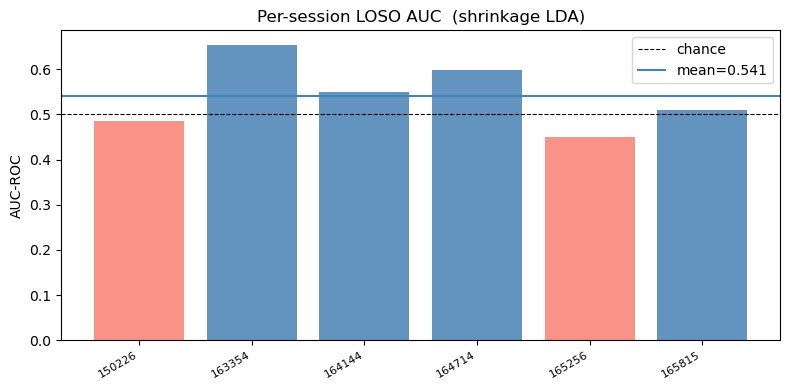

In [10]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 4))
sids   = [r["session"] for r in fold_results]
aucs   = [r["auc"]     for r in fold_results]
colors = ["steelblue" if a >= 0.5 else "salmon" for a in aucs]
ax.bar(sids, aucs, color=colors, alpha=0.85)
ax.axhline(0.5,      color="k",        linestyle="--", linewidth=0.8, label="chance")
ax.axhline(mean_auc, color="steelblue", linestyle="-",  linewidth=1.5,
           label=f"mean={mean_auc:.3f}")
ax.set_xticks(sids)
ax.set_xticklabels([r["stamp"] for r in fold_results], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUC-ROC")
ax.set_title("Per-session LOSO AUC  (shrinkage LDA)")
ax.legend()
plt.tight_layout()
plt.show()